### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import matplotlib.pyplot as plt

In [3]:
from sklearn import metrics

In [4]:
from transformers import BertTokenizer, BertForNextSentencePrediction, Trainer, TrainingArguments
from datasets import Dataset, load_dataset

In [107]:
import torch

### Step 2: Load Data

In [47]:
sentences = [
    ("The quick brown fox jumps over the lazy dog.", "The dog was not amused.", 1),  
    ("The quick brown fox jumps over the lazy dog.", "I love eating pizza.", 0),    
    ("She opened the door.", "She saw her friend standing there.", 1),               
    ("She opened the door.", "The sky was blue.", 0),                                
    ("He went to the store.", "He bought some groceries.", 1),                      
    ("He went to the store.", "It started raining heavily.", 0)                     
]

### Step 3: Preparing Data

#### Build Dataset

In [49]:
dataset = Dataset.from_dict({
    "sentence1": [s[0] for s in sentences],
    "sentence2": [s[1] for s in sentences],
    "labels": [s[2] for s in sentences]
})

In [50]:
train_test_split = dataset.train_test_split(test_size=0.2)

In [51]:
train_dataset = train_test_split['train']
test_dataset = train_test_split['test']

#### Tokenize 

In [52]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [53]:
def tokenize_function(examples):
    return tokenizer(
        examples['sentence1'], 
        examples['sentence2'], 
        truncation=True, 
        padding='max_length', 
        max_length=128
    )

In [54]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

In [55]:
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

In [98]:
model = BertForNextSentencePrediction.from_pretrained('bert-base-uncased')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForNextSentencePrediction LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [99]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
)

In [100]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = metrics.accuracy_score(labels, preds)
    return {"accuracy": acc}

In [103]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
)

In [102]:
trainer.train()

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3, training_loss=1.4001731872558594, metrics={'train_runtime': 8.5051, 'train_samples_per_second': 1.411, 'train_steps_per_second': 0.353, 'total_flos': 789333166080.0, 'train_loss': 1.4001731872558594, 'epoch': 3.0})

In [116]:
pred = trainer.predict(test_dataset)
compute_metrics(pred)

{'accuracy': 0.5}

In [108]:
probs = torch.softmax(torch.tensor(pred.predictions), dim=1).numpy()

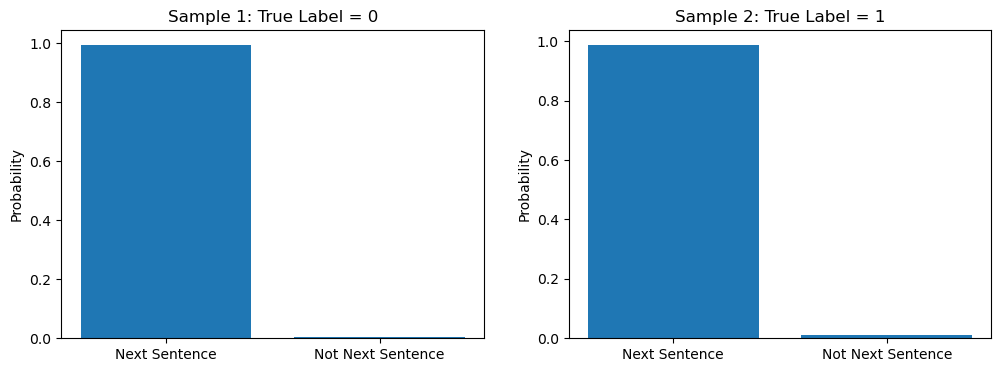

In [119]:
plt.figure(figsize=(12, 4))
for i in range(2):
    plt.subplot(1, 2, i+1)
    plt.bar(['Next Sentence', 'Not Next Sentence'], probs[i])
    plt.title(f"Sample {i+1}: True Label = {test_dataset[i]['labels']}")
    plt.ylabel("Probability")